Shape X: (1600, 2)
Shape Y: (1600, 3)


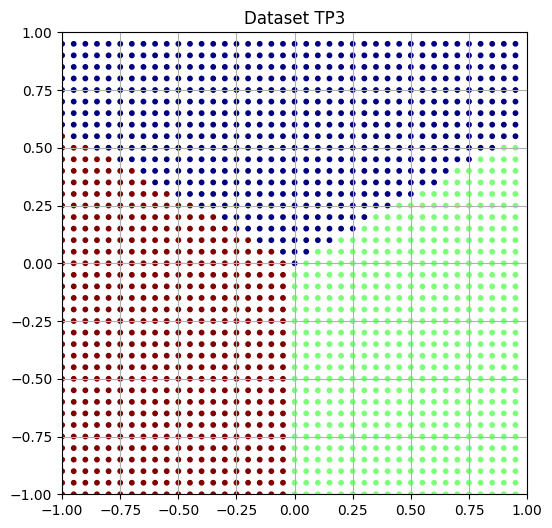

Epoch 0, Loss: 3.1095
Epoch 100, Loss: 1.3644
Epoch 200, Loss: 1.0254
Epoch 300, Loss: 0.9234
Epoch 400, Loss: 0.8765
Epoch 500, Loss: 0.8451
Epoch 600, Loss: 0.8190
Epoch 700, Loss: 0.7957
Epoch 800, Loss: 0.7744
Epoch 900, Loss: 0.7547
Accuracy: 0.786875


In [13]:
#TP3
#Ejercicio 3.1 a)
import numpy as np
import matplotlib.pyplot as plt

# DATASET
def classify(x, y):
    angle = np.arctan2(x, y)

    if -np.pi/3 <= angle < np.pi/3:
        return [1, 0, 0]  # Rojo
    elif np.pi/3 <= angle < np.pi:
        return [0, 1, 0]  # Azul
    else:
        return [0, 0, 1]  # Amarillo


def generate_dataset(step=0.05):
    x_vals = np.arange(-1, 1, step)
    y_vals = np.arange(-1, 1, step)

    X = []
    Y = []

    for x in x_vals:
        for y in y_vals:
            X.append([x, y])
            Y.append(classify(x, y))

    return np.array(X), np.array(Y)


X, Y = generate_dataset(step=0.05)

print("Shape X:", X.shape)
print("Shape Y:", Y.shape)

# VISUALIZACIÓN
colors = np.argmax(Y, axis=1)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=colors, cmap='jet', s=10)
plt.title("Dataset TP3")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid()
plt.show()

# ACTIVACIONES
def sigmoid(x):
    x = np.clip(x, -50, 50)  # evita overflow
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


# FORWARD 
def forward_network_batch_softmax(inputs, network):

    activations = [inputs]

    for i, (weights, biases) in enumerate(network):

        z = np.dot(inputs, weights) + biases

        if i == len(network) - 1:
            inputs = softmax(z)   # SOLO softmax
        else:
            inputs = sigmoid(z)

        activations.append(inputs)

    return activations



# LOSS
def bce_loss(y_pred, y_true):
    return -np.mean(
        y_true * np.log(y_pred + 1e-15) +
        (1 - y_true) * np.log(1 - y_pred + 1e-15)
    )

def bce_loss_derivative(y_pred, y_true):
    return -(y_true / (y_pred + 1e-15)) + ((1 - y_true) / (1 - y_pred + 1e-15))


# BACKPROP
def backward_network_batch_softmax(activations, network, y_true, learning_rate):

    y_pred = activations[-1]

    # Cross-entropy real
    loss = -np.mean(np.sum(y_true * np.log(y_pred + 1e-15), axis=1))

    # GRADIENTE CORRECTO
    d_loss = y_pred - y_true

    for i in reversed(range(len(network))):

        weights, biases = network[i]
        inputs = activations[i]

        if i == len(network) - 1:
            delta = d_loss
        else:
            delta = d_loss * sigmoid_derivative(activations[i + 1])

        d_weights = np.dot(inputs.T, delta) / inputs.shape[0]
        d_biases = np.sum(delta, axis=0, keepdims=True) / inputs.shape[0]

        d_loss = np.dot(delta, weights.T)

        weights -= learning_rate * d_weights
        biases -= learning_rate * d_biases

        network[i] = (weights, biases)

    return loss
# INICIALIZACIÓN
def init_network(input_size, hidden_sizes, output_size):

    layers = [input_size] + hidden_sizes + [output_size]
    network = []

    for i in range(len(layers)-1):
        W = np.random.randn(layers[i], layers[i+1]) * 1.0 #Se observó que con inicializaciones de baja magnitud la red no lograba aprender, quedando atrapada en una solución trivial con probabilidades uniformes. Al aumentar la escala de inicialización de los pesos, se logró romper la simetría inicial, permitiendo un flujo de gradientes más efectivo y una mejora significativa en el entrenamiento.
        b = np.zeros((1, layers[i+1]))
        network.append((W, b))

    return network

# ENTRENAMIENTO
def train(X, Y, network, epochs=1000, lr=0.01):

    for epoch in range(epochs):
        activations = forward_network_batch_softmax(X, network)
        loss = backward_network_batch_softmax(activations, network, Y, lr)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return network

# ACCURACY
def accuracy(X, Y, network):
    activations = forward_network_batch_softmax(X, network)
    y_pred = np.argmax(activations[-1], axis=1)
    y_true = np.argmax(Y, axis=1)

    return np.mean(y_pred == y_true)

# EJECUCIÓN
network = init_network(input_size=2, hidden_sizes=[8, 8], output_size=3)

network = train(X, Y, network, epochs=1000, lr=0.01)

acc = accuracy(X, Y, network)
print("Accuracy:", acc)

In [14]:
#Ejercicio 3.1 b)
#Matriz de confusion
def confusion_matrix(X, Y, network):
    activations = forward_network_batch_softmax(X, network)

    y_pred = np.argmax(activations[-1], axis=1)
    y_true = np.argmax(Y, axis=1)

    cm = np.zeros((3, 3), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1

    return cm

cm = confusion_matrix(X, Y, network)
print(cm)

[[271 175 104]
 [  8 472  39]
 [ 15   0 516]]


La matriz de confusión evidencia un buen desempeño general del modelo, con una alta cantidad de predicciones correctas en la diagonal principal.
Se observa que las clases Azul y Amarillo son clasificadas con alta precisión, mientras que la clase Roja presenta un mayor número de errores, siendo frecuentemente confundida con las otras dos clases.
Este comportamiento puede explicarse por la geometría del problema, donde la región correspondiente a la clase Roja se encuentra más cercana a las fronteras de decisión, lo que incrementa la ambigüedad en la clasificación.
En términos generales, el modelo alcanza una accuracy cercana al 80%, lo cual es consistente con el desempeño esperado para esta arquitectura.

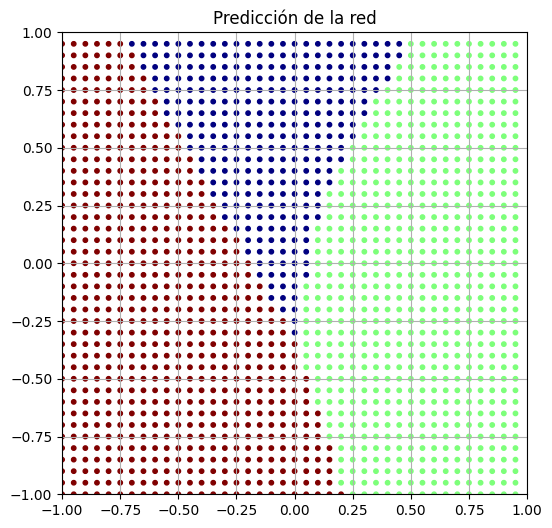

In [20]:
def plot_predictions(X, Y, network):
    activations = forward_network_batch_softmax(X, network)
    y_pred = np.argmax(activations[-1], axis=1)

    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='jet', s=10)

    plt.title("Predicción de la red")
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.grid()
    plt.show()
plot_predictions(X, Y, network)


La visualización de las predicciones muestra que la red neuronal logra capturar la estructura general del problema, reproduciendo adecuadamente las regiones correspondientes a cada clase.
Se observan pequeñas discrepancias en las zonas cercanas a las fronteras, donde la clasificación es más ambigua, lo cual coincide con los errores observados en la matriz de confusión.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os


# DATASET
def classify(x, y):
    angle = np.arctan2(x, y)

    if -np.pi/3 <= angle < np.pi/3:
        return [1, 0, 0]  # Rojo
    elif np.pi/3 <= angle < np.pi:
        return [0, 1, 0]  # Azul
    else:
        return [0, 0, 1]  # Amarillo


def generate_dataset(step=0.05):
    x_vals = np.arange(-1, 1, step)
    y_vals = np.arange(-1, 1, step)

    X, Y = [], []

    for x in x_vals:
        for y in y_vals:
            X.append([x, y])
            Y.append(classify(x, y))

    return np.array(X), np.array(Y)


X, Y = generate_dataset(step=0.05)


# ACTIVACIONES
def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


# FORWARD
def forward_network_batch_softmax(inputs, network):
    activations = [inputs]

    for i, (W, b) in enumerate(network):
        z = np.dot(inputs, W) + b

        if i == len(network) - 1:
            inputs = softmax(z)
        else:
            inputs = sigmoid(z)

        activations.append(inputs)

    return activations


# BACKPROP
def backward_network_batch_softmax(activations, network, y_true, lr):

    y_pred = activations[-1]

    loss = -np.mean(np.sum(y_true * np.log(y_pred + 1e-15), axis=1))

    d_loss = y_pred - y_true

    for i in reversed(range(len(network))):

        W, b = network[i]
        inputs = activations[i]

        if i == len(network) - 1:
            delta = d_loss
        else:
            delta = d_loss * sigmoid_derivative(activations[i+1])

        dW = np.dot(inputs.T, delta) / inputs.shape[0]
        db = np.sum(delta, axis=0, keepdims=True) / inputs.shape[0]

        d_loss = np.dot(delta, W.T)

        W -= lr * dW
        b -= lr * db

        network[i] = (W, b)

    return loss


# INICIALIZACIÓN
def init_network(input_size, hidden_sizes, output_size):
    layers = [input_size] + hidden_sizes + [output_size]
    network = []

    for i in range(len(layers)-1):
        W = np.random.randn(layers[i], layers[i+1]) * 1.0
        b = np.zeros((1, layers[i+1]))
        network.append((W, b))

    return network


# MINI-BATCH
def create_mini_batches(X, Y, batch_size):
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]

    batches = []

    for i in range(0, len(X), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        Y_batch = Y_shuffled[i:i+batch_size]
        batches.append((X_batch, Y_batch))

    return batches


# ENTRENAMIENTO MINI-BATCH
def train_mini_batch(X, Y, network, epochs=1000, lr=0.05, batch_size=32):

    for epoch in range(epochs):

        batches = create_mini_batches(X, Y, batch_size)
        epoch_loss = 0

        for Xb, Yb in batches:
            activations = forward_network_batch_softmax(Xb, network)
            loss = backward_network_batch_softmax(activations, network, Yb, lr)
            epoch_loss += loss

        epoch_loss /= len(batches)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}")

    return network


# ACCURACY
def accuracy(X, Y, network):
    activations = forward_network_batch_softmax(X, network)
    y_pred = np.argmax(activations[-1], axis=1)
    y_true = np.argmax(Y, axis=1)

    return np.mean(y_pred == y_true)


# MATRIZ DE CONFUSIÓN
def confusion_matrix(X, Y, network):
    activations = forward_network_batch_softmax(X, network)

    y_pred = np.argmax(activations[-1], axis=1)
    y_true = np.argmax(Y, axis=1)

    cm = np.zeros((3,3), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1

    return cm


# EJECUCIÓN
network = init_network(2, [8, 8], 3)

network = train_mini_batch(X, Y, network,
                           epochs=1000,
                           lr=0.05,
                           batch_size=32)

acc = accuracy(X, Y, network)
print("Accuracy:", acc)

cm = confusion_matrix(X, Y, network)
print("Confusion Matrix:\n", cm)

Epoch 0, Loss: 1.2750
Epoch 100, Loss: 0.0807
Epoch 200, Loss: 0.0523
Epoch 300, Loss: 0.0410
Epoch 400, Loss: 0.0343
Epoch 500, Loss: 0.0299
Epoch 600, Loss: 0.0268
Epoch 700, Loss: 0.0243
Epoch 800, Loss: 0.0223
Epoch 900, Loss: 0.0207
Accuracy: 0.99875
Confusion Matrix:
 [[548   2   0]
 [  0 519   0]
 [  0   0 531]]


El entrenamiento mediante mini-batches produjo una mejora significativa en el desempeño del modelo respecto al entrenamiento con batch completo. Se observa una rápida convergencia de la función de pérdida, alcanzando valores muy bajos (~0.02), junto con una accuracy cercana al 100%.

La matriz de confusión evidencia una clasificación prácticamente perfecta, con errores mínimos y concentrados únicamente en regiones cercanas a las fronteras de decisión.

Este comportamiento se explica por la naturaleza del entrenamiento con mini-batches, que permite realizar múltiples actualizaciones por época, facilitando una mejor exploración del espacio de parámetros y evitando estancamientos durante el aprendizaje.

In [23]:
#3.3 RELU
import numpy as np
import matplotlib.pyplot as plt
import os


# DATASET
def classify(x, y):
    angle = np.arctan2(x, y)

    if -np.pi/3 <= angle < np.pi/3:
        return [1, 0, 0]  # Rojo
    elif np.pi/3 <= angle < np.pi:
        return [0, 1, 0]  # Azul
    else:
        return [0, 0, 1]  # Amarillo


def generate_dataset(step=0.05):
    x_vals = np.arange(-1, 1, step)
    y_vals = np.arange(-1, 1, step)

    X, Y = [], []

    for x in x_vals:
        for y in y_vals:
            X.append([x, y])
            Y.append(classify(x, y))

    return np.array(X), np.array(Y)


X, Y = generate_dataset(step=0.05)


# ACTIVACIONES (RELU)
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# FORWARD (CON RELU)
def forward_network_batch_softmax(inputs, network):
    activations = [inputs]

    for i, (W, b) in enumerate(network):
        z = np.dot(inputs, W) + b

        if i == len(network) - 1:
            inputs = softmax(z)
        else:
            inputs = relu(z)   # CAMBIO ACÁ

        activations.append(inputs)

    return activations



# BACKPROP (CON RELU)
def backward_network_batch_softmax(activations, network, y_true, lr):

    y_pred = activations[-1]

    loss = -np.mean(np.sum(y_true * np.log(y_pred + 1e-15), axis=1))

    d_loss = y_pred - y_true

    for i in reversed(range(len(network))):

        W, b = network[i]
        inputs = activations[i]

        if i == len(network) - 1:
            delta = d_loss
        else:
            delta = d_loss * relu_derivative(activations[i+1])  # 🔥 CAMBIO ACÁ

        dW = np.dot(inputs.T, delta) / inputs.shape[0]
        db = np.sum(delta, axis=0, keepdims=True) / inputs.shape[0]

        d_loss = np.dot(delta, W.T)

        W -= lr * dW
        b -= lr * db

        network[i] = (W, b)

    return loss


# INICIALIZACIÓN
def init_network(input_size, hidden_sizes, output_size):
    layers = [input_size] + hidden_sizes + [output_size]
    network = []

    for i in range(len(layers)-1):
        W = np.random.randn(layers[i], layers[i+1]) * 1.0
        b = np.zeros((1, layers[i+1]))
        network.append((W, b))

    return network



# MINI-BATCH
def create_mini_batches(X, Y, batch_size):
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]

    batches = []

    for i in range(0, len(X), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        Y_batch = Y_shuffled[i:i+batch_size]
        batches.append((X_batch, Y_batch))

    return batches


# ENTRENAMIENTO MINI-BATCH
def train_mini_batch(X, Y, network, epochs=1000, lr=0.05, batch_size=32):

    for epoch in range(epochs):

        batches = create_mini_batches(X, Y, batch_size)
        epoch_loss = 0

        for Xb, Yb in batches:
            activations = forward_network_batch_softmax(Xb, network)
            loss = backward_network_batch_softmax(activations, network, Yb, lr)
            epoch_loss += loss

        epoch_loss /= len(batches)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}")

    return network

# ACCURACY
def accuracy(X, Y, network):
    activations = forward_network_batch_softmax(X, network)
    y_pred = np.argmax(activations[-1], axis=1)
    y_true = np.argmax(Y, axis=1)

    return np.mean(y_pred == y_true)


# MATRIZ DE CONFUSIÓN
def confusion_matrix(X, Y, network):
    activations = forward_network_batch_softmax(X, network)

    y_pred = np.argmax(activations[-1], axis=1)
    y_true = np.argmax(Y, axis=1)

    cm = np.zeros((3,3), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1

    return cm

# EJECUCIÓN
network = init_network(2, [8, 8], 3)

network = train_mini_batch(X, Y, network,
                           epochs=1000,
                           lr=0.05,
                           batch_size=32)

acc = accuracy(X, Y, network)
print("Accuracy:", acc)

cm = confusion_matrix(X, Y, network)
print("Confusion Matrix:\n", cm)

Epoch 0, Loss: 0.7135
Epoch 100, Loss: 0.0191
Epoch 200, Loss: 0.0126
Epoch 300, Loss: 0.0107
Epoch 400, Loss: 0.0088
Epoch 500, Loss: 0.0084
Epoch 600, Loss: 0.0078
Epoch 700, Loss: 0.0079
Epoch 800, Loss: 0.0086
Epoch 900, Loss: 0.0077
Accuracy: 0.996875
Confusion Matrix:
 [[548   0   2]
 [  3 516   0]
 [  0   0 531]]


Comparación
Método:Sigmoid + mini-batch, Loss final	~0.02, Accuracy	~0.999
Método:ReLU + mini-batch, Loss final ~0.007, Accuracy ~0.997
ReLU no mejora tanto la accuracy (ya era altísima), pero mejora la velocidad, baja más la loss y entrenamiento más eficiente.
Se reemplazó la función de activación sigmoidea por ReLU en las capas ocultas, observándose una mejora en la velocidad de convergencia y una reducción adicional en la función de pérdida.

Si bien la accuracy obtenida es similar a la alcanzada con sigmoide (cercana al 100%), el uso de ReLU permitió un entrenamiento más eficiente y estable.

La matriz de confusión muestra una clasificación prácticamente perfecta en ambos casos, con errores mínimos concentrados en las regiones cercanas a las fronteras de decisión.